In [1]:
import kagglehub
gold_price_prediction_dataset_path = kagglehub.dataset_download('sid321axn/gold-price-prediction-dataset')
print('Data source import complete.')

Using Colab cache for faster access to the 'gold-price-prediction-dataset' dataset.
Data source import complete.


In [2]:
import pandas as pd
df = pd.read_csv(gold_price_prediction_dataset_path+'/FINAL_USO.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,SP_open,SP_high,SP_low,...,GDX_Low,GDX_Close,GDX_Adj Close,GDX_Volume,USO_Open,USO_High,USO_Low,USO_Close,USO_Adj Close,USO_Volume
0,2011-12-15,154.740005,154.949997,151.710007,152.330002,152.330002,21521900,123.029999,123.199997,121.989998,...,51.570000,51.680000,48.973877,20605600,36.900002,36.939999,36.049999,36.130001,36.130001,12616700
1,2011-12-16,154.309998,155.369995,153.899994,155.229996,155.229996,18124300,122.230003,122.949997,121.300003,...,52.040001,52.680000,49.921513,16285400,36.180000,36.500000,35.730000,36.270000,36.270000,12578800
2,2011-12-19,155.479996,155.860001,154.360001,154.869995,154.869995,12547200,122.059998,122.320000,120.029999,...,51.029999,51.169998,48.490578,15120200,36.389999,36.450001,35.930000,36.200001,36.200001,7418200
3,2011-12-20,156.820007,157.429993,156.580002,156.979996,156.979996,9136300,122.180000,124.139999,120.370003,...,52.369999,52.990002,50.215282,11644900,37.299999,37.610001,37.220001,37.560001,37.560001,10041600
4,2011-12-21,156.979996,157.529999,156.130005,157.160004,157.160004,11996100,123.930000,124.360001,122.750000,...,52.419998,52.959999,50.186852,8724300,37.669998,38.240002,37.520000,38.110001,38.110001,10728000


# Date column

In [3]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')
df.head()

,Open,High,Low,Close,Adj Close,Volume,SP_open,SP_high,SP_low,SP_close,...,GDX_Low,GDX_Close,GDX_Adj Close,GDX_Volume,USO_Open,USO_High,USO_Low,USO_Close,USO_Adj Close,USO_Volume
Date,,,,,,,,,,,,,,,,,,,,,
2011-12-15,154.740005,154.949997,151.710007,152.330002,152.330002,21521900,123.029999,123.199997,121.989998,122.180000,...,51.570000,51.680000,48.973877,20605600,36.900002,36.939999,36.049999,36.130001,36.130001,12616700
2011-12-16,154.309998,155.369995,153.899994,155.229996,155.229996,18124300,122.230003,122.949997,121.300003,121.589996,...,52.040001,52.680000,49.921513,16285400,36.180000,36.500000,35.730000,36.270000,36.270000,12578800
2011-12-19,155.479996,155.860001,154.360001,154.869995,154.869995,12547200,122.059998,122.320000,120.029999,120.290001,...,51.029999,51.169998,48.490578,15120200,36.389999,36.450001,35.930000,36.200001,36.200001,7418200
2011-12-20,156.820007,157.429993,156.580002,156.979996,156.979996,9136300,122.180000,124.139999,120.370003,123.930000,...,52.369999,52.990002,50.215282,11644900,37.299999,37.610001,37.220001,37.560001,37.560001,10041600
2011-12-21,156.979996,157.529999,156.130005,157.160004,157.160004,11996100,123.930000,124.360001,122.750000,124.169998,...,52.419998,52.959999,50.186852,8724300,37.669998,38.240002,37.520000,38.110001,38.110001,10728000


# Stationarity check



In [4]:
from statsmodels.tsa.stattools import adfuller

adf_test = adfuller(df['Close'])
print('p-value: %f' % adf_test[1])
if adf_test[1] < 0.05:
    print('The time series is likely stationary.')
else:
    print('The time series is likely non-stationary.')

p-value: 0.368878
The time series is likely non-stationary.


# Implement AR, MA, ARMA, and ARIMA models


In [5]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import train_test_split

close_price = df['Close']
train_data, test_data = train_test_split(close_price, test_size=0.2, shuffle=False)

In [6]:
# Fit AR model
ar_model = ARIMA(train_data, order=(1, 0, 0))
ar_results = ar_model.fit()
ar_predictions = ar_results.predict(start=len(train_data), end=len(df)-1)

# Fit MA model
ma_model = ARIMA(train_data, order=(0, 0, 1))
ma_results = ma_model.fit()
ma_predictions = ma_results.predict(start=len(train_data), end=len(df)-1)

# Fit ARMA model
arma_model = ARIMA(train_data, order=(1, 0, 1))
arma_results = arma_model.fit()
arma_predictions = arma_results.predict(start=len(train_data), end=len(df)-1)

# Fit ARIMA model
# Since the ADF test indicated non-stationarity (p-value > 0.05),
# we will use differencing (d=1) for the ARIMA model.
# We can analyze ACF and PACF of the differenced series to determine p and q,
# but for simplicity, we'll start with (1, 1, 1) as a common starting point.
arima_model = ARIMA(train_data, order=(1, 1, 1))
arima_results = arima_model.fit()
arima_predictions = arima_results.predict(start=len(train_data), end=len(df)-1)

print("AR Predictions:")
print(ar_predictions.head())
print("\nMA Predictions:")
print(ma_predictions.head())
print("\nARMA Predictions:")
print(arma_predictions.head())
print("\nARIMA Predictions:")
print(arima_predictions.head())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

AR Predictions:
1374    122.228490
1375    122.246933
1376    122.265329
1377    122.283678
1378    122.301981
Name: predicted_mean, dtype: float64

MA Predictions:
1374    124.591803
1375    128.958518
1376    128.958518
1377    128.958518
1378    128.958518
Name: predicted_mean, dtype: float64

ARMA Predictions:
1374    122.175599
1375    122.198814
1376    122.221976
1377    122.245084
1378    122.268138
Name: predicted_mean, dtype: float64

ARIMA Predictions:
1374    122.121508
1375    122.095731
1376    122.088222
1377    122.086035
1378    122.085398
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


## Implement SARIMA



In [7]:

from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(train_data, order=(1, 1, 1), seasonal_order=(1, 0, 0, 12))
sarima_results = sarima_model.fit()

sarima_predictions = sarima_results.predict(start=len(train_data), end=len(df)-1)
print("SARIMA Predictions:")
print(sarima_predictions.head())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


SARIMA Predictions:
1374    122.124733
1375    122.098809
1376    122.094483
1377    122.092545
1378    122.091582
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


# Implement exponential smoothing


In [8]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

exp_smoothing_model = ExponentialSmoothing(train_data, trend='add', seasonal='add', seasonal_periods=12)
exp_smoothing_results = exp_smoothing_model.fit()


exp_smoothing_predictions = exp_smoothing_results.predict(start=len(train_data), end=len(df)-1)
print("Exponential Smoothing Predictions:")
print(exp_smoothing_predictions.head())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Exponential Smoothing Predictions:
1374    122.218432
1375    122.194669
1376    122.199856
1377    121.981000
1378    121.951722
dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


# Implement linear trend model


In [9]:
import numpy as np

In [10]:
from sklearn.linear_model import LinearRegression

train_time_steps = np.arange(len(train_data)).reshape(-1, 1)
linear_trend_model = LinearRegression()

linear_trend_model.fit(train_time_steps, train_data)
test_time_steps = np.arange(len(train_data), len(df)).reshape(-1, 1)

linear_trend_predictions = linear_trend_model.predict(test_time_steps)
print("Linear Trend Predictions:")
print(linear_trend_predictions[:5])

Linear Trend Predictions:
[103.24931826 103.21192722 103.17453617 103.13714513 103.09975408]


# Implement prophet


In [12]:
from prophet import Prophet
from sklearn.model_selection import ParameterGrid
from prophet.diagnostics import cross_validation, performance_metrics

prophet_train_df = train_data.reset_index().rename(columns={'Date': 'ds', 'Close': 'y'})
param_grid = {
    'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0],
    'n_changepoints': [5, 10, 20, 25]
}

all_params = list(ParameterGrid(param_grid))
rmses = []

for params in all_params:
    prophet_model = Prophet(**params)
    prophet_model.fit(prophet_train_df)
    df_cv = cross_validation(prophet_model, initial='730 days', period='180 days', horizon='365 days')
    df_p = performance_metrics(df_cv, metrics=['rmse'])
    rmses.append(df_p['rmse'].mean())

best_params = all_params[np.argmin(rmses)]
print(f"Best parameters: {best_params}")

prophet_model = Prophet(**best_params)
prophet_model.fit(prophet_train_df)

future = prophet_model.make_future_dataframe(periods=len(test_data))

prophet_predictions = prophet_model.predict(future)['yhat']

print("\nProphet Predictions (with best parameters):")
print(prophet_predictions.head())

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpq_sskw48/o6t8lxq6.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpq_sskw48/osdx2x8v.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=41580', 'data', 'file=/tmp/tmpq_sskw48/o6t8lxq6.json', 'init=/tmp/tmpq_sskw48/osdx2x8v.json', 'output', 'file=/tmp/tmpq_sskw48/prophet_model8b9wjbm7/prophet_model-20250926020012.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
02:00:12 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
02:00:12 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:Making 6 forecasts with cutoffs between 2014-02-22 00:00:00 and 2016-08-10 00:00:00


  0%|          | 0/6 [00:00<?, ?it/s]

DEBUG:cmdstanpy:input tempfile: /tmp/tmpq_sskw48/g9y86f6g.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpq_sskw48/vgscjra4.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=5898', 'data', 'file=/tmp/tmpq_sskw48/g9y86f6g.json', 'init=/tmp/tmpq_sskw48/vgscjra4.json', 'output', 'file=/tmp/tmpq_sskw48/prophet_model7nrc8k73/prophet_model-20250926020013.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
02:00:13 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
02:00:13 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmpq_sskw48/mbg04p4u.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpq_sskw48/66abrlfe.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/l

  0%|          | 0/6 [00:00<?, ?it/s]

DEBUG:cmdstanpy:input tempfile: /tmp/tmpq_sskw48/uh6hvfj5.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpq_sskw48/yvtkl8ve.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=68271', 'data', 'file=/tmp/tmpq_sskw48/uh6hvfj5.json', 'init=/tmp/tmpq_sskw48/yvtkl8ve.json', 'output', 'file=/tmp/tmpq_sskw48/prophet_modelijtbwiba/prophet_model-20250926020018.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
02:00:18 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
02:00:18 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmpq_sskw48/vl751gis.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpq_sskw48/8hj7xeqf.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/

...

  0%|          | 0/6 [00:00<?, ?it/s]

DEBUG:cmdstanpy:input tempfile: /tmp/tmpq_sskw48/03vz788a.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpq_sskw48/0xeip9i5.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=91717', 'data', 'file=/tmp/tmpq_sskw48/03vz788a.json', 'init=/tmp/tmpq_sskw48/0xeip9i5.json', 'output', 'file=/tmp/tmpq_sskw48/prophet_model_mr_jbgl/prophet_model-20250926020430.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
02:04:30 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
02:04:31 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmpq_sskw48/ef8mym01.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpq_sskw48/3nk7blsk.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/

Best parameters: {'changepoint_prior_scale': 0.5, 'n_changepoints': 20, 'seasonality_prior_scale': 0.01}


02:04:38 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing



Prophet Predictions (with best parameters):
0    157.185671
1    157.010430
2    156.384281
3    156.208316
4    156.003629
Name: yhat, dtype: float64


# Evaluate models


In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt

def evaluate_model(actual, predicted):
    rmse = sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    return rmse, mae

evaluation_results = {}

In [15]:
start_index = len(train_data)
end_index = len(df) - 1

ar_predictions = ar_results.predict(start=start_index, end=end_index)
ma_predictions = ma_results.predict(start=start_index, end=end_index)
arma_predictions = arma_results.predict(start=start_index, end=end_index)
arima_predictions = arima_results.predict(start=start_index, end=end_index)
sarima_predictions = sarima_results.predict(start=start_index, end=end_index)
exp_smoothing_predictions = exp_smoothing_results.predict(start=start_index, end=end_index)

ar_rmse, ar_mae = evaluate_model(test_data, ar_predictions)
evaluation_results['AR'] = {'RMSE': ar_rmse, 'MAE': ar_mae}

ma_rmse, ma_mae = evaluate_model(test_data, ma_predictions)
evaluation_results['MA'] = {'RMSE': ma_rmse, 'MAE': ma_mae}

arma_rmse, arma_mae = evaluate_model(test_data, arma_predictions)
evaluation_results['ARMA'] = {'RMSE': arma_rmse, 'MAE': arma_mae}

arima_rmse, arima_mae = evaluate_model(test_data, arima_predictions)
evaluation_results['ARIMA'] = {'RMSE': arima_rmse, 'MAE': arima_mae}

sarima_rmse, sarima_mae = evaluate_model(test_data, sarima_predictions)
evaluation_results['SARIMA'] = {'RMSE': sarima_rmse, 'MAE': sarima_mae}

exp_smoothing_rmse, exp_smoothing_mae = evaluate_model(test_data, exp_smoothing_predictions)
evaluation_results['Exponential Smoothing'] = {'RMSE': exp_smoothing_rmse, 'MAE': exp_smoothing_mae}

linear_trend_rmse, linear_trend_mae = evaluate_model(test_data, linear_trend_predictions)
evaluation_results['Linear Trend'] = {'RMSE': linear_trend_rmse, 'MAE': linear_trend_mae}

# Select only the predictions corresponding to the test data for Prophet
prophet_test_predictions = prophet_predictions.iloc[-len(test_data):]
prophet_rmse, prophet_mae = evaluate_model(test_data, prophet_test_predictions)
evaluation_results['Prophet'] = {'RMSE': prophet_rmse, 'MAE': prophet_mae}

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-pa

# Compare results


In [18]:
evaluation_df = pd.DataFrame.from_dict(evaluation_results, orient='index')
evaluation_df = evaluation_df.sort_values(by=['RMSE', 'MAE'])

print("Model Performance Summary (Sorted by RMSE):")
display(evaluation_df)  # Without tuning Prophet MAE was 11 and now 8.2

Model Performance Summary (Sorted by RMSE):


,RMSE,MAE
Exponential Smoothing,4.367539,3.444128
ARIMA,4.810051,3.960755
SARIMA,4.813096,3.961722
AR,6.694451,5.097839
ARMA,7.308632,5.499119
MA,9.389440,8.161551
Prophet,10.780054,8.209735
Linear Trend,24.205057,23.947519


# Visualize predictions

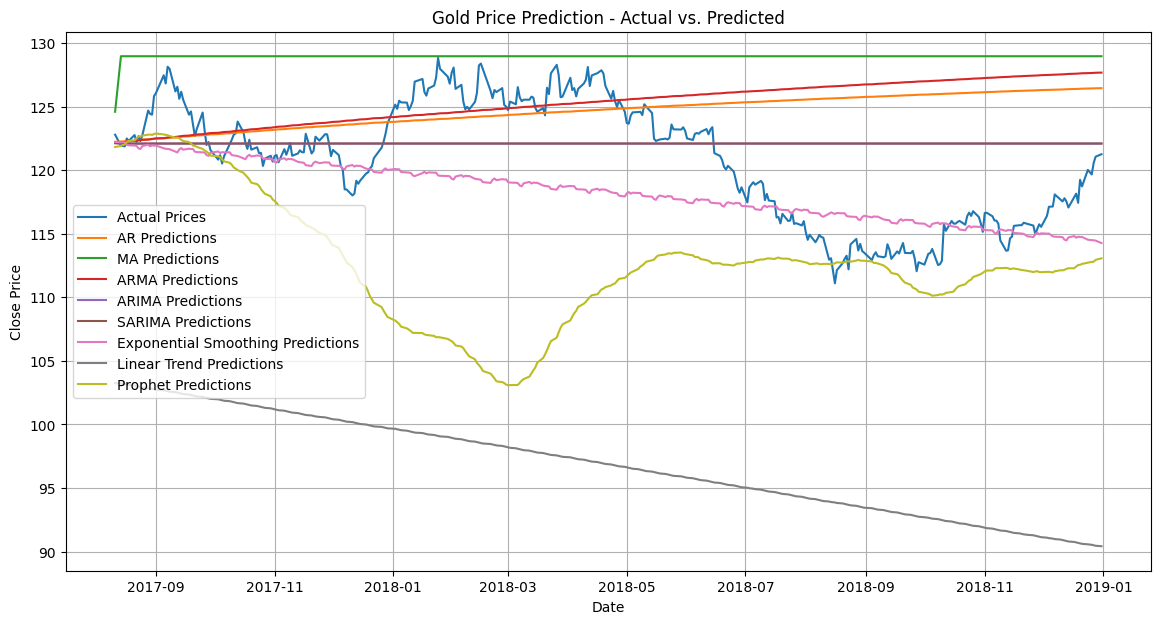

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
plt.plot(test_data.index, test_data, label='Actual Prices')
plt.plot(test_data.index, ar_predictions, label='AR Predictions')
plt.plot(test_data.index, ma_predictions, label='MA Predictions')
plt.plot(test_data.index, arma_predictions, label='ARMA Predictions')
plt.plot(test_data.index, arima_predictions, label='ARIMA Predictions')
plt.plot(test_data.index, sarima_predictions, label='SARIMA Predictions')
plt.plot(test_data.index, exp_smoothing_predictions, label='Exponential Smoothing Predictions')
plt.plot(test_data.index, linear_trend_predictions, label='Linear Trend Predictions')
plt.plot(test_data.index, prophet_test_predictions, label='Prophet Predictions')


plt.title('Gold Price Prediction - Actual vs. Predicted')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()